# **CMSC 320 - FINAL PROJECT**

In [3]:
#imports
import pandas as pd
import string
import math
import matplotlib.pyplot as plt

**PART 1 - DATA PROCESSING**

We are using Earthquake data from the USGS earthquake data website.  This data is from June 1st, 2005 to September 27th, 2012. It includes not only earthquake data but data involving Volcano Eruption and Landsides all of which has been reviewd in the context of Earthquakes.

In [4]:
earthquakes_df = pd.read_csv("Earthquakes.csv")
earthquakes_df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2005-06-01T12:24:21.490Z,18.4620,-68.7530,148.1,4.2,mb,47.0,47.7,NaN,NaN,...,2014-11-07T01:26:03.100Z,"9 km WNW of San Rafael del Yuma, Dominican Rep...",earthquake,NaN,NaN,NaN,11.0,reviewed,rspr,us
1,2005-06-01T21:55:04.580Z,17.0910,-46.4740,10.0,5.0,mwc,241.0,44.7,NaN,0.72,...,2025-12-19T23:08:34.930Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2005-06-01T21:58:40.450Z,17.0670,-46.4480,10.0,4.8,mb,81.0,46.4,NaN,0.69,...,2014-11-07T01:26:04.203Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,30.0,reviewed,us,us
3,2005-06-02T04:50:07.800Z,19.4800,-103.5720,7.0,4.1,md,6.0,104.8,NaN,NaN,...,2014-11-07T01:26:04.430Z,"5 km NNW of Cofradía, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,unm,unm
4,2005-06-02T09:29:38.580Z,26.4510,-44.7070,10.0,4.7,mb,21.0,128.4,NaN,1.16,...,2014-11-07T01:26:04.558Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,12.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2012-09-26T11:37:27.550Z,10.2180,-85.1100,57.1,4.2,mb,31.0,196.4,NaN,0.86,...,2014-11-07T01:48:55.204Z,"17 km WSW of Juntas, Costa Rica",earthquake,NaN,5.3,NaN,13.0,reviewed,us,us
15996,2012-09-26T18:15:22.200Z,14.8520,-61.2440,169.6,4.3,md,32.0,136.9,NaN,NaN,...,2014-11-07T01:48:55.280Z,"13 km W of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,trn,trn
15997,2012-09-26T22:23:23.940Z,26.8630,-44.2400,10.0,4.4,mb,40.0,88.6,NaN,1.04,...,2014-11-07T01:48:55.300Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,10.0,reviewed,us,us
15998,2012-09-27T03:03:41.090Z,9.8210,-85.5690,36.7,4.4,mb,60.0,139.7,NaN,1.36,...,2014-11-07T01:48:55.505Z,"8 km SW of Sámara, Costa Rica",earthquake,NaN,9.5,NaN,32.0,reviewed,us,us


Information about the dataset before any modifications take place

In [5]:
print(f"df.shape: {earthquakes_df.shape}")
earthquakes_df.shape
print("df.describe(): ")
display(earthquakes_df.describe())
print("df.info(): ")
earthquakes_df.info()

df.shape: (16000, 22)
df.describe(): 


,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,16000.000000,16000.000000,16000.000000,16000.00000,14720.000000,14717.000000,1490.000000,7664.000000,1513.000000,4770.000000,1176.000000,6173.000000
mean,27.611573,-104.703152,38.187911,4.10787,47.583628,168.173160,0.278961,0.850562,1.483323,14.140468,0.191622,51.673092
std,16.763399,31.873068,43.143381,0.49540,77.578092,79.883874,0.357982,0.889954,5.029209,155.091728,0.157575,84.415456
min,7.959000,-171.562000,-2.285000,3.50000,0.000000,11.900000,0.001802,0.009800,0.080000,0.000000,0.000000,0.000000
25%,15.886000,-120.798542,10.000000,3.70000,8.000000,107.000000,0.054320,0.570000,0.300000,0.500000,0.134000,5.000000
50%,18.629000,-98.362000,19.000000,4.00000,18.000000,170.200000,0.166600,0.920000,0.580000,4.025000,0.163000,15.000000
75%,40.308958,-87.848000,51.700000,4.40000,49.000000,219.800000,0.392775,1.150000,1.630000,12.000000,0.200000,50.000000
max,72.852000,-36.609000,294.900000,7.60000,857.000000,358.300000,5.654000,69.320000,99.000000,9117.600000,1.680000,438.000000


df.info(): 
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             16000 non-null  str    
 1   latitude         16000 non-null  float64
 2   longitude        16000 non-null  float64
 3   depth            16000 non-null  float64
 4   mag              16000 non-null  float64
 5   magType          16000 non-null  str    
 6   nst              14720 non-null  float64
 7   gap              14717 non-null  float64
 8   dmin             1490 non-null   float64
 9   rms              7664 non-null   float64
 10  net              16000 non-null  str    
 11  id               16000 non-null  str    
 12  updated          16000 non-null  str    
 13  place            16000 non-null  str    
 14  type             16000 non-null  str    
 15  horizontalError  1513 non-null   float64
 16  depthError       4770 non-null   float64
 17  magError   

Parse data: Sort by magnitude

In [6]:
#sort by mag highest to smallest
earthquakes_df = earthquakes_df.sort_values(by=['mag'], ascending=False).reset_index(drop='True')

#this line below is to check if there was mag error, there is, maybe we could use it
#earthquakes_df = earthquakes_df.dropna(subset=['magError'])

#date only column, in datetime (remove .dt.date to get full date and time in datetime format)
date = pd.to_datetime(earthquakes_df['time']).dt.date
earthquakes_df.insert(0, 'date', date)
display(earthquakes_df)

,date,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2012-09-05,2012-09-05T14:42:07.800Z,10.0850,-85.3150,35.0,7.6,mww,703.0,34.3,NaN,...,2025-01-03T07:43:01.170Z,"11 km ENE of Hojancha, Costa Rica",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
1,2012-03-20,2012-03-20T18:02:47.440Z,16.4930,-98.2310,20.0,7.4,mww,672.0,37.9,NaN,...,2022-05-03T15:34:09.063Z,"6 km E of Santiago Llano Grande, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
2,2007-11-29,2007-11-29T19:00:20.420Z,14.9440,-61.2740,156.0,7.4,mwb,663.0,13.4,NaN,...,2022-07-13T02:37:48.411Z,"18 km WNW of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
3,2009-05-28,2009-05-28T08:24:46.560Z,16.7310,-86.2170,19.0,7.3,mwc,464.0,27.2,NaN,...,2025-07-03T19:11:11.454Z,"46 km NW of Guanaja, Honduras",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gcmt
4,2012-08-27,2012-08-27T04:37:19.430Z,12.1390,-88.5900,28.0,7.3,mww,417.0,37.0,NaN,...,2022-05-03T15:48:15.643Z,"126 km S of Puerto El Triunfo, El Salvador",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2005-06-07,2005-06-07T15:48:56.030Z,18.5400,-66.0820,106.6,3.5,md,14.0,193.8,NaN,...,2014-11-07T01:26:09.142Z,"8 km NNE of San Juan, Puerto Rico",earthquake,NaN,NaN,NaN,NaN,reviewed,rspr,rspr
15996,2006-05-10,2006-05-10T02:49:16.060Z,52.5390,-169.1980,25.3,3.5,ml,5.0,215.0,NaN,...,2019-02-13T04:32:18.731Z,"49 km SSW of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic
15997,2005-06-02,2005-06-02T20:18:52.006Z,62.2733,-147.9050,1.4,3.5,ml,NaN,NaN,NaN,...,2019-02-13T02:59:22.783Z,"53 km NNW of Glacier View, Alaska",earthquake,NaN,1.0,NaN,NaN,reviewed,ak,ak
15998,2005-06-02,2005-06-02T17:38:56.100Z,15.6050,-96.3430,32.3,3.5,md,4.0,291.4,NaN,...,2014-11-07T01:26:04.992Z,"17 km ESE of Puerto Ángel, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,unm,unm


Graph plotted below for Method 1: Based on magnitude and depth


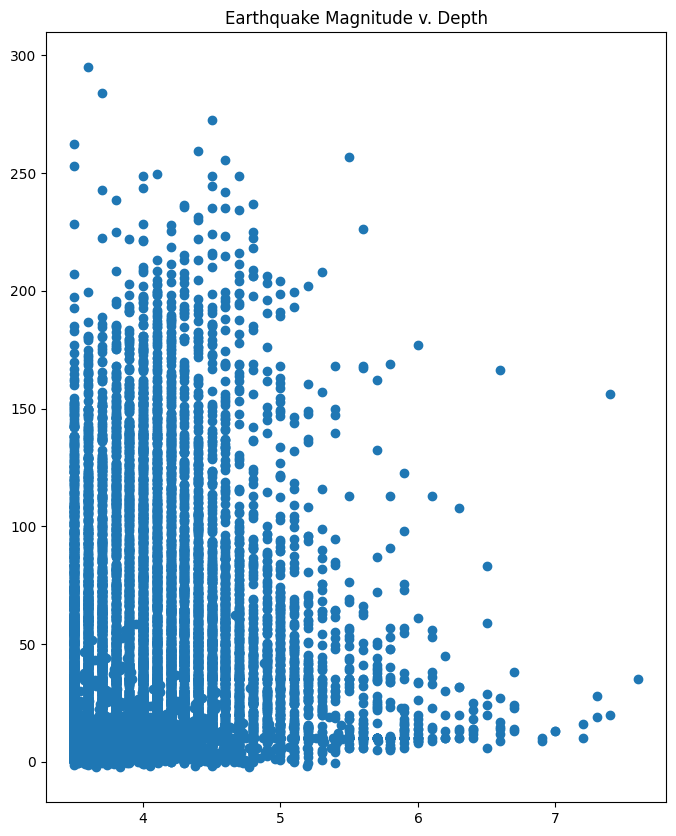

In [7]:
#write code here to plot graph this is mag v depth

#but this looks like a lot, maybes we just plot frequency of mags,
#or we narrow the range (groupby locationSource) for 'us' in locationSource before we plot
plt.figure(figsize=(8, 10))
plt.scatter(earthquakes_df['mag'], earthquakes_df['depth'])
plt.title("Earthquake Magnitude v. Depth")
plt.show()

Graph plotted below for Method 2: 


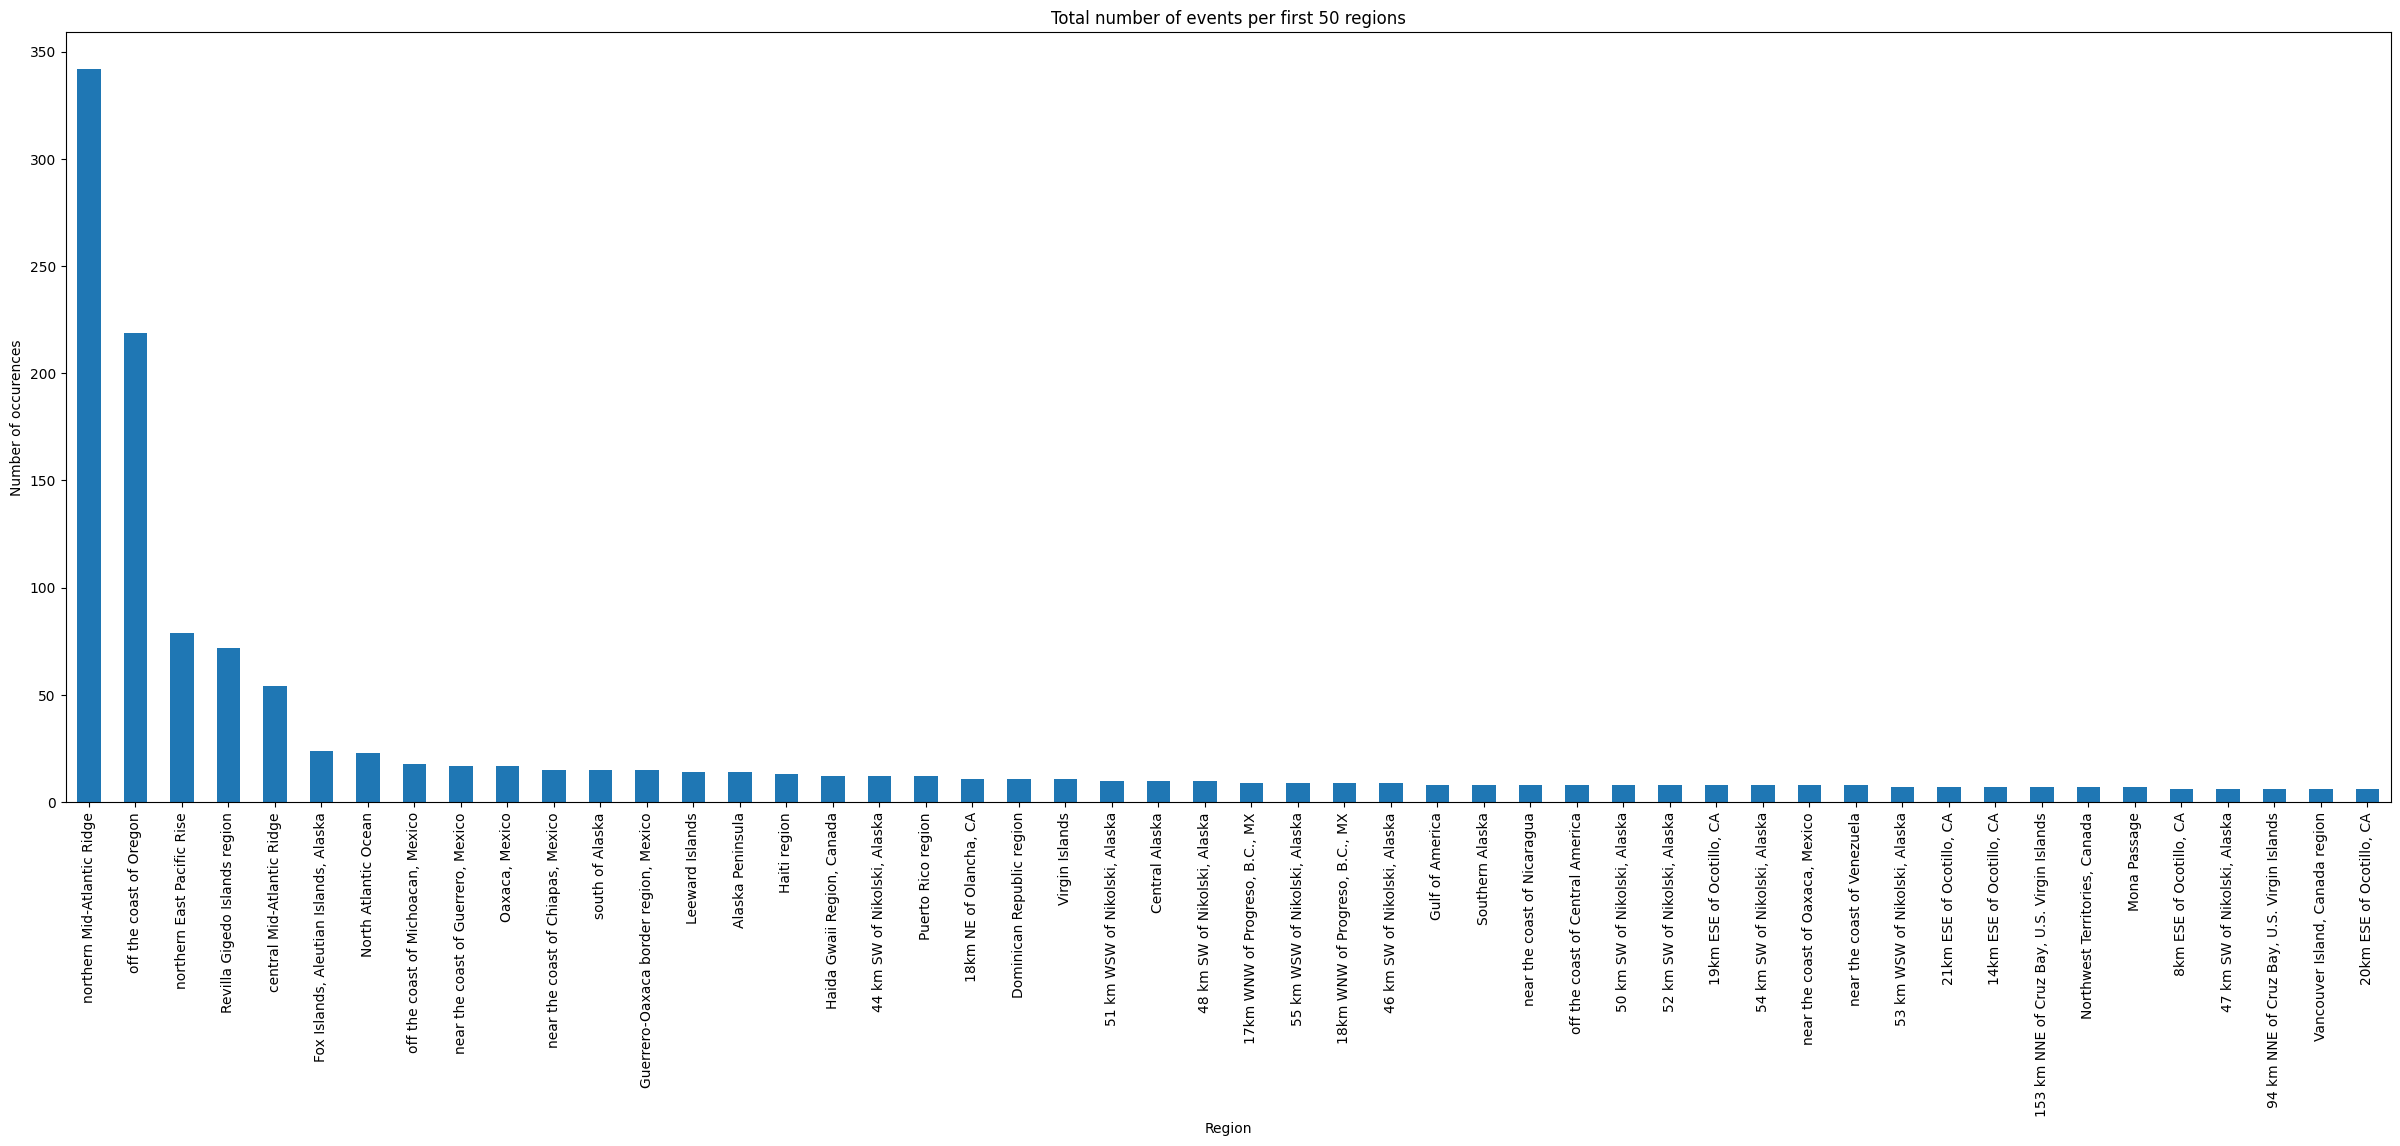

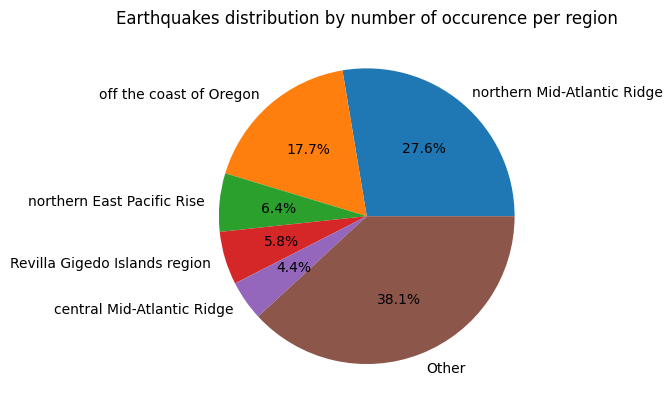

place
northern Mid-Atlantic Ridge              342
off the coast of Oregon                  219
northern East Pacific Rise                79
Revilla Gigedo Islands region             72
central Mid-Atlantic Ridge                54
Fox Islands, Aleutian Islands, Alaska     24
North Atlantic Ocean                      23
off the coast of Michoacan, Mexico        18
near the coast of Guerrero, Mexico        17
Oaxaca, Mexico                            17
near the coast of Chiapas, Mexico         15
south of Alaska                           15
Guerrero-Oaxaca border region, Mexico     15
Leeward Islands                           14
Alaska Peninsula                          14
Haiti region                              13
Haida Gwaii Region, Canada                12
44 km SW of Nikolski, Alaska              12
Puerto Rico region                        12
18km NE of Olancha, CA                    11
Dominican Republic region                 11
Virgin Islands                            11
51 k

In [ ]:
#method 2
place_types = earthquakes_df['place'].value_counts().head(50)


#bins = range(0, place_types.max() + 25, 25)
#binned = pd.cut(place_types, bins = bins)
#binned_occurences = binned.value_counts().sort_index()


place_types.plot(kind='bar', figsize=(30,10))
plt.title('Total number of events per first 50 regions')
plt.xlabel('Region')
plt.ylabel('Number of occurences')
plt.show()

mycount = place_types[place_types > 50].count()  #5

place_types_more_than_50_occurences = place_types[place_types > 30]

place_types_for_piechart = place_types_more_than_50_occurences.copy()
place_types_for_piechart['Other'] = place_types[place_types < 30].sum()



place_types_for_piechart.plot(kind='pie', autopct='%1.1f%%')

plt.title("Earthquakes distribution by number of occurence per region")
plt.show()

#place_types.head(30)


Graph plotted below for Method 3 (Hypothesis): _________


In [ ]:
#method 3